# BINF 4211: Applied Data Mining for Bioinformatics.

## Lab: t-SNE

## Learning goals

By the end of this notebook, students should be able to:

1. Explain the intuition behind t-SNE.
2. Understand what t-SNE preserves well and what it does **not** preserve well.
3. Run t-SNE in Python using `scikit-learn`.
4. Compare t-SNE with PCA.
5. Interpret the effects of parameters such as:
   - `perplexity`
   - `learning_rate`
   - `max_iter`
6. Recognize common pitfalls when interpreting t-SNE plots.

## Important teaching message

t-SNE is mainly a **visualization tool**. It is excellent for showing **local neighborhood structure** in high-dimensional data, but it is **not** a general-purpose clustering method and should be interpreted carefully.



## 1. Intuition of t-SNE

Suppose each sample is a point in a high-dimensional space.

t-SNE tries to build a low-dimensional map (usually 2D) so that:

- points that are **near each other** in high dimensions stay near each other in 2D,
- while points that are far apart are not modeled as carefully.

### High-level idea

t-SNE works in two stages conceptually:

1. In the original high-dimensional space, it converts pairwise distances into **similarities** (probabilities of being neighbors).
2. In the low-dimensional map, it also defines similarities between points.
3. It then adjusts the 2D coordinates so the low-dimensional similarities match the high-dimensional similarities as closely as possible.

### Why the "t" in t-SNE?

The low-dimensional similarities use a **Student t-distribution** rather than a Gaussian.
This helps reduce the **crowding problem**, allowing moderately distant points to spread out better in 2D.

### What t-SNE is good at

- Revealing local structure
- Showing groups of similar samples
- Visualizing nonlinear structure

### What t-SNE is not good at

- Preserving global distances faithfully
- Proving that clusters are truly separated
- Supporting strong conclusions from the exact distances between cluster centers


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



## 2. A simple synthetic dataset

We begin with an easy synthetic dataset created from several blobs in a higher-dimensional space.
This helps us see how PCA and t-SNE behave on the same data.


In [2]:

# Create synthetic data in 10 dimensions
X_syn, y_syn = make_blobs(
    n_samples=500,
    n_features=10,
    centers=4,
    cluster_std=2.5,
    random_state=42
)

print("Shape of X_syn:", X_syn.shape)
print("Unique class labels:", np.unique(y_syn))


Shape of X_syn: (500, 10)
Unique class labels: [0 1 2 3]


In [3]:

# PCA to 2D
pca_2d = PCA(n_components=2, random_state=42)
X_syn_pca = pca_2d.fit_transform(X_syn)

# t-SNE to 2D
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_syn_tsne = tsne_2d.fit_transform(X_syn)


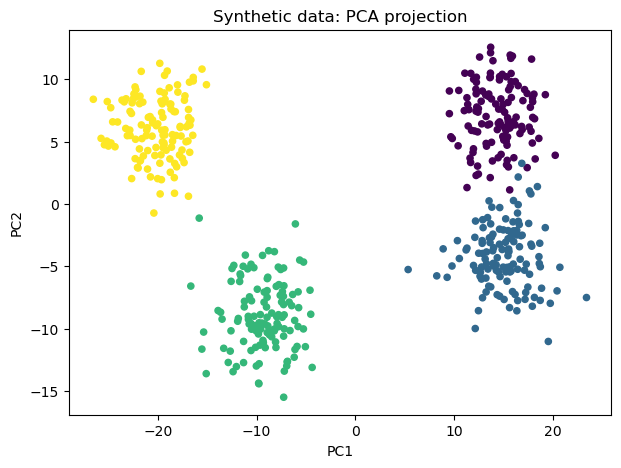

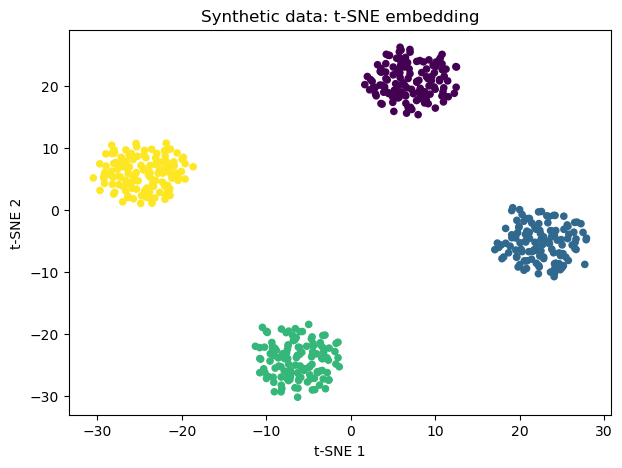

In [4]:

plt.figure(figsize=(7, 5))
plt.scatter(X_syn_pca[:, 0], X_syn_pca[:, 1], c=y_syn, s=20)
plt.title("Synthetic data: PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_syn_tsne[:, 0], X_syn_tsne[:, 1], c=y_syn, s=20)
plt.title("Synthetic data: t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()



### Discussion

Questions for students:

1. Which method seems to separate nearby groups more clearly?
2. Does t-SNE always produce a "better" result than PCA?
3. Can we trust the distances between the centers of the t-SNE groups?

**Teaching point:**  
t-SNE often gives visually striking separation, but that does **not** automatically mean the original data truly contains sharply separated clusters in a global geometric sense.



## 3. A real dataset example: handwritten digits

We now use the classic `digits` dataset from scikit-learn.

- Each sample is an 8×8 image of a digit.
- Each image is represented by **64 features**.
- The class label is the digit (0 through 9).

This is a nice teaching dataset because the original dimension is larger than 2, and the classes are meaningful.


In [5]:

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("X_digits shape:", X_digits.shape)
print("Number of classes:", len(np.unique(y_digits)))


X_digits shape: (1797, 64)
Number of classes: 10



### Why standardize?

For many datasets, standardization is important before dimensionality reduction.
For pixel intensity data like `digits`, scaling is not always absolutely necessary, but it is still a useful habit in general machine learning workflows.

Here we standardize the features before PCA and t-SNE.


In [6]:

scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)


In [7]:

# PCA on digits
pca_digits = PCA(n_components=2, random_state=42)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

# t-SNE on digits
tsne_digits = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_digits_tsne = tsne_digits.fit_transform(X_digits_scaled)


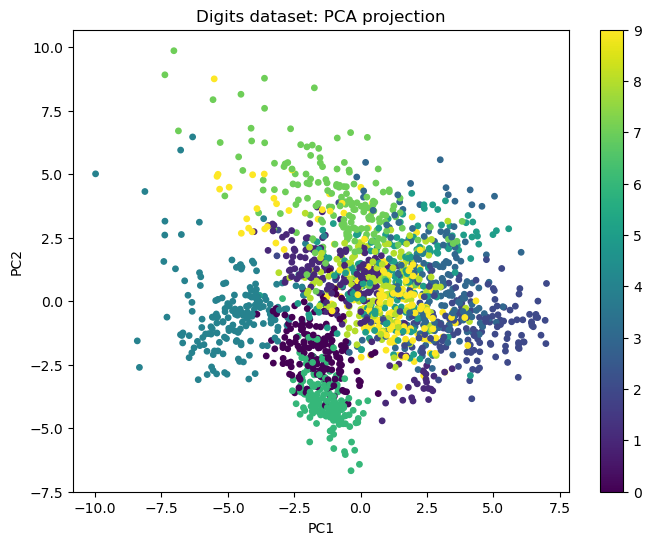

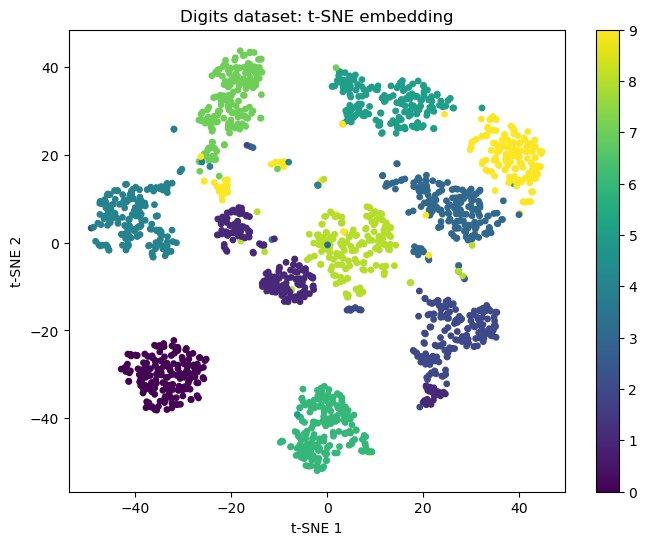

In [8]:

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], c=y_digits, s=15)
plt.title("Digits dataset: PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_digits, s=15)
plt.title("Digits dataset: t-SNE embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter)
plt.show()



## 4. Quantitative note: be careful

Students often ask whether t-SNE is "better" because the plot looks nicer.

A useful caution is:

- t-SNE is optimized for neighborhood preservation and visualization,
- not for producing a representation whose axes have direct meaning,
- and not for formal cluster validation by itself.

Below, we compute a silhouette score **in the 2D projected space only**.  
This is shown for teaching purposes, but it should **not** be overinterpreted as proof that t-SNE is objectively superior.

The score can change because the geometry itself is changed by the projection.


In [9]:

sil_pca = silhouette_score(X_digits_pca, y_digits)
sil_tsne = silhouette_score(X_digits_tsne, y_digits)

print(f"Silhouette score in PCA 2D space:   {sil_pca:.3f}")
print(f"Silhouette score in t-SNE 2D space: {sil_tsne:.3f}")


Silhouette score in PCA 2D space:   0.055
Silhouette score in t-SNE 2D space: 0.485



## 5. Understanding perplexity

`perplexity` is one of the most important t-SNE parameters.

A simple teaching intuition:

- smaller perplexity emphasizes very local neighborhoods,
- larger perplexity uses a broader notion of neighborhood.

Typical values are often between **5 and 50**, but the best value depends on the dataset size and structure.

Let's see how the embedding changes as we vary perplexity.


In [10]:

perplexities = [5, 30, 50]

embeddings_perp = {}
for p in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    embeddings_perp[p] = tsne.fit_transform(X_digits_scaled)


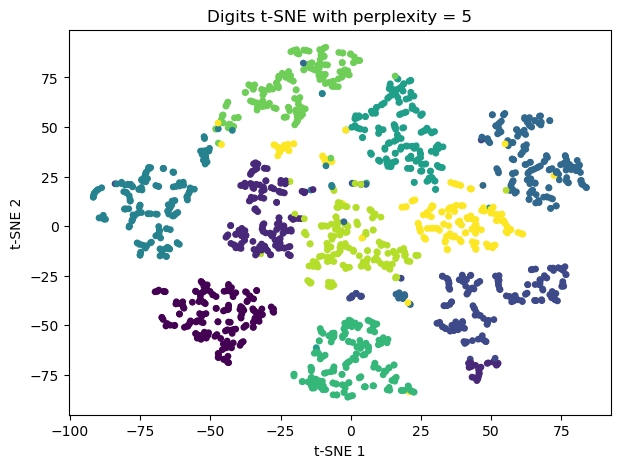

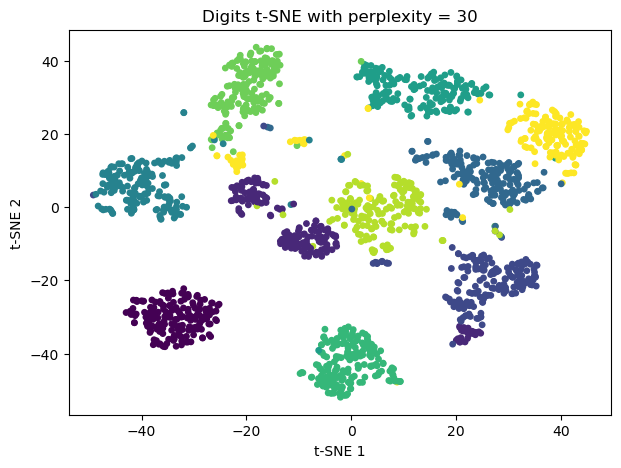

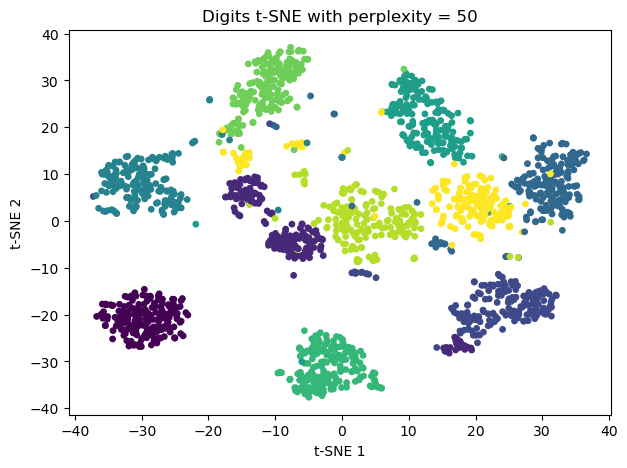

In [11]:

for p in perplexities:
    plt.figure(figsize=(7, 5))
    plt.scatter(embeddings_perp[p][:, 0], embeddings_perp[p][:, 1], c=y_digits, s=15)
    plt.title(f"Digits t-SNE with perplexity = {p}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()



### Interpretation

1. Which perplexity makes the groups look most separated?
2. Do some embeddings look artificially fragmented?
3. Why should we avoid choosing the "best" perplexity only because it looks nicest?

**Key idea:**  
A visually appealing embedding is not automatically the most truthful or useful one.



## 6. Understanding learning rate

Another important parameter is the learning rate.

Very roughly:

- if the learning rate is too small, optimization may move too slowly or get stuck in poor-looking arrangements,
- if it is too large, the embedding can become unstable or distorted.

Let's compare a few values.


In [12]:

learning_rates = [10, 200, 1000]

embeddings_lr = {}
for lr in learning_rates:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=lr,
        init="pca",
        random_state=42
    )
    embeddings_lr[lr] = tsne.fit_transform(X_digits_scaled)


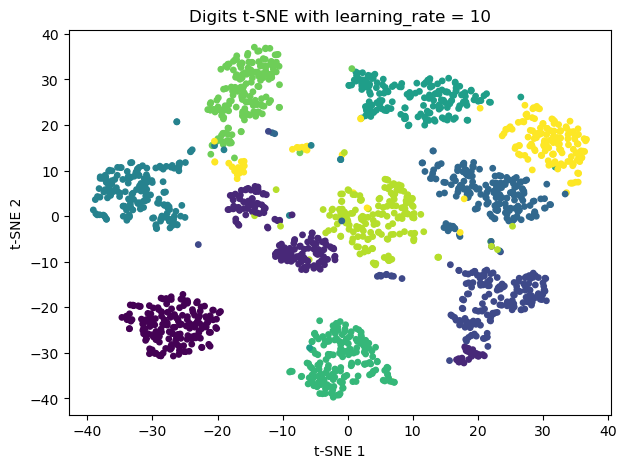

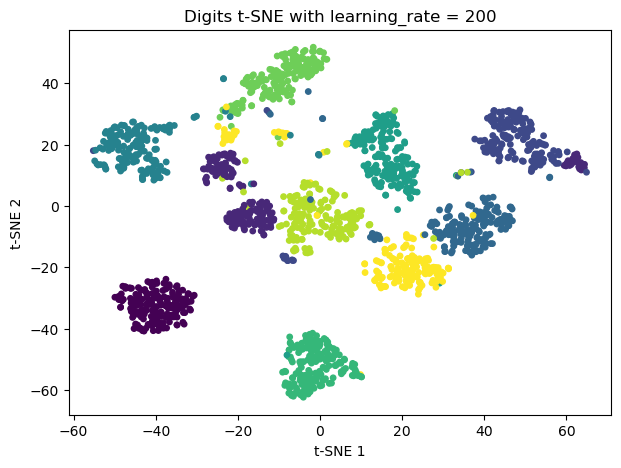

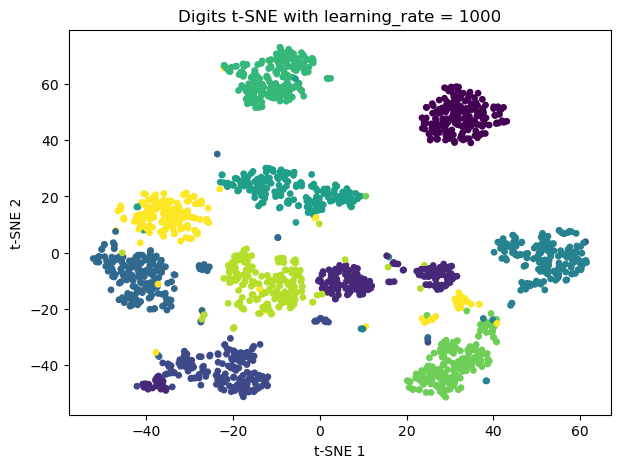

In [13]:

for lr in learning_rates:
    plt.figure(figsize=(7, 5))
    plt.scatter(embeddings_lr[lr][:, 0], embeddings_lr[lr][:, 1], c=y_digits, s=15)
    plt.title(f"Digits t-SNE with learning_rate = {lr}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()



## 7. Why different runs may look different

t-SNE is usually **not deterministic** unless you fix the random seed.

Even with the same dataset and same parameters, different random initializations can produce somewhat different maps.

Important points:

- the exact orientation of the map does not matter,
- the exact absolute coordinates do not matter,
- what matters more is the local neighborhood structure.

Below we compare different random seeds.


In [14]:

random_states = [0, 7, 42]

embeddings_seed = {}
for rs in random_states:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=rs
    )
    embeddings_seed[rs] = tsne.fit_transform(X_digits_scaled)


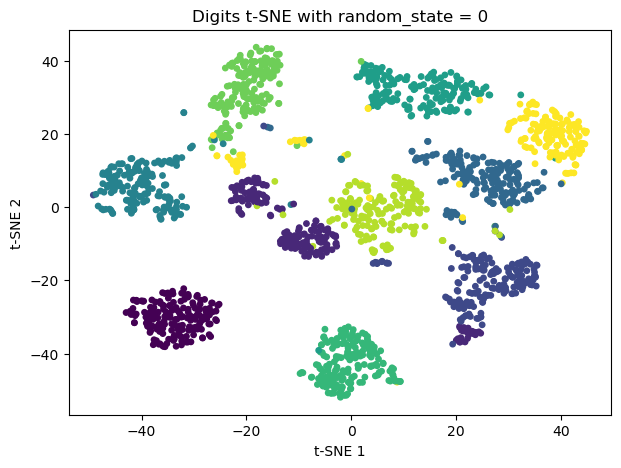

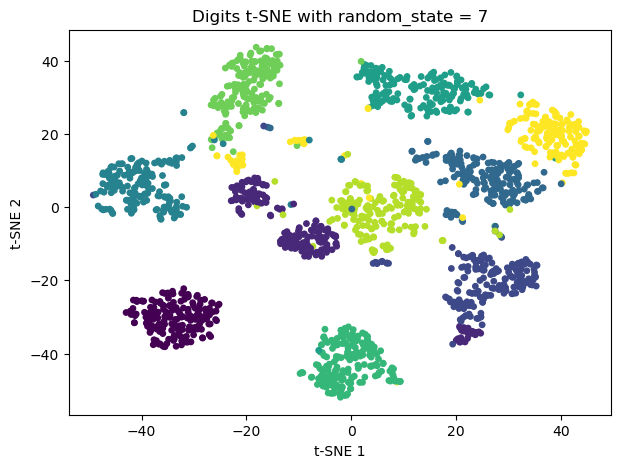

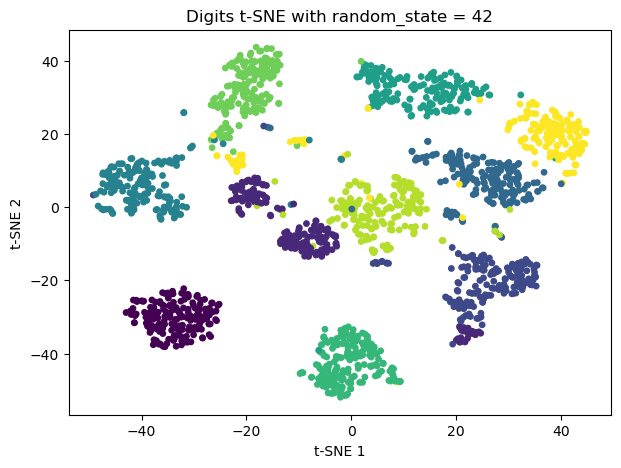

In [15]:

for rs in random_states:
    plt.figure(figsize=(7, 5))
    plt.scatter(embeddings_seed[rs][:, 0], embeddings_seed[rs][:, 1], c=y_digits, s=15)
    plt.title(f"Digits t-SNE with random_state = {rs}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()



## 8. Common interpretation mistakes

### Mistake 1: "Clusters in t-SNE prove natural classes exist."
Not necessarily. t-SNE tends to separate local neighborhoods visually.

### Mistake 2: "The distance between two t-SNE clusters is meaningful."
Usually not in a strict global geometric sense.

### Mistake 3: "The size of a t-SNE cluster represents the true variance of that class."
Not reliably.

### Mistake 4: "The axes have direct interpretation."
They usually do not.

### Mistake 5: "t-SNE is a clustering algorithm."
It is a nonlinear dimensionality reduction / visualization method, not a clustering algorithm.

A better practice is to combine t-SNE with:
- domain knowledge,
- labels (if available),
- PCA,
- clustering methods used separately and evaluated carefully.



## 9. Practical recommendations

When using t-SNE in practice:

1. Standardize features when appropriate.
2. Often reduce dimension first with PCA (for example to 30–50 PCs) before t-SNE, especially for large datasets.
3. Try several perplexity values.
4. Use a fixed `random_state` for reproducibility.
5. Do not overinterpret global distances and empty space between groups.
6. Use t-SNE mainly for **exploration and visualization**.



## 10. Example workflow: PCA before t-SNE

In many real applications, especially with high-dimensional biological data, a common workflow is:

1. Standardize the data.
2. Use PCA to reduce noise and dimension.
3. Run t-SNE on the PCA scores.

Below we apply PCA to 30 dimensions first, then run t-SNE.


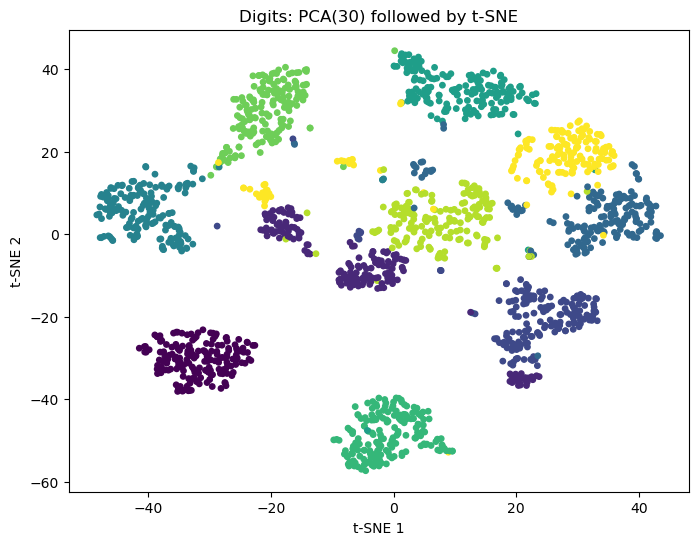

In [16]:

pca_30 = PCA(n_components=30, random_state=42)
X_digits_pca30 = pca_30.fit_transform(X_digits_scaled)

tsne_after_pca = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_digits_tsne_after_pca = tsne_after_pca.fit_transform(X_digits_pca30)

plt.figure(figsize=(8, 6))
plt.scatter(X_digits_tsne_after_pca[:, 0], X_digits_tsne_after_pca[:, 1], c=y_digits, s=15)
plt.title("Digits: PCA(30) followed by t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()



## 11. Summary

### Main ideas to remember

- t-SNE is a **nonlinear visualization method**.
- It preserves **local neighborhoods** better than global geometry.
- It often reveals structure more clearly than PCA in 2D visualizations.
- Results depend on parameters such as perplexity and learning rate.
- The plot should be interpreted with caution.

### One-sentence takeaway

t-SNE is a powerful tool for exploring high-dimensional data visually, but it should be used as an **interpretive aid**, not as final proof of biological or statistical truth.



## 12. Suggested exercises

1. Change the perplexity to 10, 20, 40, and 60.  
   How does the plot change?

2. Change the random seed.  
   What parts of the embedding remain stable?

3. Compare:
   - PCA to 2D
   - t-SNE to 2D
   - PCA to 30D followed by t-SNE

4. Use another dataset from `scikit-learn`, such as `wine` or `breast_cancer`.

5. For a bioinformatics extension:
   imagine rows are samples and columns are gene expression values.  
   How would you preprocess the data before applying t-SNE?



## 13. Optional discussion questions

1. Why might a nonlinear method like t-SNE show separation that PCA does not?
2. Why can t-SNE be visually persuasive but also potentially misleading?
3. In bioinformatics, when would t-SNE be especially useful?
4. Why is it dangerous to claim that a t-SNE plot "proves" subtypes exist?
5. Why might PCA-before-t-SNE be a good idea in high-dimensional omics data?



## 14. Minimal template for students

Here is a compact version students can reuse on their own data:

```python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# X is your data matrix: rows=samples, columns=features
X_scaled = StandardScaler().fit_transform(X)

# Optional: PCA first
X_pca = PCA(n_components=30, random_state=42).fit_transform(X_scaled)

# t-SNE
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
).fit_transform(X_pca)

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE embedding")
plt.show()
```
